### Optimising strategy parameters formax returns 

In [64]:
import sys
!"{sys.executable}" -m pip install --upgrade pip
!"{sys.executable}" -m pip install --upgrade scikit-optimize backtesting

  Using cached pip-25.1.1-py3-none-any.whl.metadata (3.6 kB)
Using cached pip-25.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1


In [3]:
import pickle 

In [4]:
with open('models/model_dtr_regression.pkl', 'rb') as f: 
    model_dtr = pickle.load(f)

In [5]:
import pandas as pd

In [6]:
df = pd.read_excel('data/Microsoft_LinkedIn_Processed.xlsx', parse_dates=['Date'], index_col=0)
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,55.079998,55.594599,54.926523,55.341812,21220800,1.549152,UP
2016-12-09,55.946697,55.964754,55.188343,55.233482,27349400,0.321693,UP
2016-12-12,56.127254,56.244620,55.720996,55.811275,20198100,1.286142,UP
2016-12-13,56.858536,57.255768,56.190463,56.425191,35718900,-0.478626,DOWN
2016-12-14,56.587692,57.282851,56.452270,56.876589,30352700,-0.159799,DOWN
...,...,...,...,...,...,...,...
2025-05-16,454.269989,454.359985,448.730011,452.049988,23849800,1.002464,UP
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500,-0.152778,DOWN
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800,-1.237379,DOWN


In [7]:
model_dtr

DecisionTreeRegressor(max_depth=15)

In [65]:
from backtesting import Backtest, Strategy

In [9]:
class Regression(Strategy):
    limit_buy = 1
    limit_sell = -5

    def init(self):
        self.model = model_dtr
        self.already_bought = False

    def next(self):
        explanatory_today = self.data.df.iloc[[-1], :] 
        forecast_tomorrow = model_dtr.predict(explanatory_today)[0] 

        #improve stratgy to get higher equity via changign the numbers here or using the bt optimisation method
        if forecast_tomorrow > self.limit_buy and self.already_bought == False: #5% inc 
            self.buy() 
            self.already_bought = True 
        elif forecast_tomorrow < self.limit_sell and self.already_bought== True: #5% dec
            self.sell() 
            self.already_bought = False
        else: 
            pass
            

In [10]:
df_explanatory = df.drop(columns=['change_tomorrow',	'change_tomorrow_direction'])

In [11]:
bt = Backtest(df_explanatory, Regression, cash=10000, commission=.002, exclusive_orders=True)

### Optimising w xxx combos 

In [12]:
list_limits_buy = list(range(0, 11, 1))
list_limits_buy

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [13]:
list_limit_sell = list(range(0, -11, -1))
list_limit_sell

[0, -1, -2, -3, -4, -5, -6, -7, -8, -9, -10]

In [ ]:
%%timeit
results = bt.optimize(
    limit_buy = list_limits_buy,
    limit_sell = list_limit_sell, 
    maximize= 'Return [%]',#can max any val in the results table 
    return_heatmap=True
)

c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\backtesting.py:1606: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_stats.py:155: RuntimeWarning: divide by zero encountered in log
  equity_log_returns = np.log(equity[1:] / equity[:-1])
c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_stats.py:155: RuntimeWarning: divide by zero encountered in log
  equity_log_returns = np.log(equity[1:] / equity[:-1])
c:\U

In [ ]:
results 
#an obj that contains xxx objs inside as it startsw brakcets 

(Start                     2016-12-08 00:00:00
 End                       2025-05-22 00:00:00
 Duration                   3087 days 00:00:00
 Exposure Time [%]                    99.71765
 Equity Final [$]                 1834061.0296
 Equity Peak [$]                 1857352.88747
 Commissions [$]                  690040.81106
 Return [%]                         18240.6103
 Buy & Hold Return [%]                 725.817
 Return (Ann.) [%]                    85.53004
 Volatility (Ann.) [%]                50.42429
 CAGR [%]                             53.02714
 Sharpe Ratio                          1.69621
 Sortino Ratio                         5.21231
 Calmar Ratio                          2.60385
 Alpha [%]                         17930.72154
 Beta                                  0.42695
 Max. Drawdown [%]                   -32.84757
 Avg. Drawdown [%]                    -2.63716
 Max. Drawdown Duration      244 days 00:00:00
 Avg. Drawdown Duration       13 days 00:00:00
 # Trades    

In [ ]:
results[0] 
#geenral results


Start                     2016-12-08 00:00:00
End                       2025-05-22 00:00:00
Duration                   3087 days 00:00:00
Exposure Time [%]                    99.71765
Equity Final [$]                 1834061.0296
Equity Peak [$]                 1857352.88747
Commissions [$]                  690040.81106
Return [%]                         18240.6103
Buy & Hold Return [%]                 725.817
Return (Ann.) [%]                    85.53004
Volatility (Ann.) [%]                50.42429
CAGR [%]                             53.02714
Sharpe Ratio                          1.69621
Sortino Ratio                         5.21231
Calmar Ratio                          2.60385
Alpha [%]                         17930.72154
Beta                                  0.42695
Max. Drawdown [%]                   -32.84757
Avg. Drawdown [%]                    -2.63716
Max. Drawdown Duration      244 days 00:00:00
Avg. Drawdown Duration       13 days 00:00:00
# Trades                          

In [ ]:
results[1]
#diff returns for each iteration of sell and buy value tried

limit_buy  limit_sell
0           0            18240.610296
           -1            12314.369308
           -2             4581.348697
           -3             2535.305098
           -4             1753.818189
                             ...     
10         -6             -100.000000
           -7             -100.000000
           -8             -100.000000
           -9             -100.000000
           -10            -100.000000
Name: Return [%], Length: 121, dtype: float64

### Pands reporting w heatmap - intepret optimisation results

In [ ]:
#turn the results into a df with the func reset_index()
dff = results[1].reset_index()

In [ ]:
#create a pivot table 
dff = dff.pivot(index='limit_buy', columns='limit_sell', values='Return [%]')

In [ ]:
#sort the columns so they start from 0 
#then style df to rep info with decimals to create the heatmap
#vmin to make the cells darker base don the overall max value 
dff.sort_index(axis=1, ascending=False)\
    .style.format(precision=0)\
    .background_gradient(vmin=dff.values.min(), vmax=dff.values.max())

#best cobo = limit sell and limit buy 0
#can see ome results at -100, goign to use the optimise func to avoid values with such low results 

limit_sell,0,-1,-2,-3,-4,-5,-6,-7,-8,-9,-10
limit_buy,,,,,,,,,,,
0,18241,12314,4581,2535,1754,882,832,719,701,674,674
1,831,2311,4183,1747,1931,1051,992,710,692,665,665
2,-59,-23,65,87,217,429,401,333,321,438,438
3,-83,-72,-77,-62,-62,185,169,242,292,438,438
4,-83,-78,-79,-76,-57,114,61,106,137,333,333
5,-82,-78,-77,-75,-57,161,97,106,137,333,333
6,-100,-100,-100,-100,35,70,29,34,48,173,173
7,-100,-100,-100,-100,-100,-100,-100,-100,-100,219,219
8,-100,-100,-100,-100,-100,-100,-100,-100,-100,201,201


### Smart optimisation to save computing time 

In [ ]:
#strategically select limit buy and sell that gives best results 
#based on numerical methods 

In [14]:
with open('models/model_dtr_regression.pkl', 'rb') as f: 
    model_dtr = pickle.load(f)

In [15]:
df = pd.read_excel('data/Microsoft_LinkedIn_Processed.xlsx', parse_dates=['Date'], index_col=0)
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,55.079998,55.594599,54.926523,55.341812,21220800,1.549152,UP
2016-12-09,55.946697,55.964754,55.188343,55.233482,27349400,0.321693,UP
2016-12-12,56.127254,56.244620,55.720996,55.811275,20198100,1.286142,UP
2016-12-13,56.858536,57.255768,56.190463,56.425191,35718900,-0.478626,DOWN
2016-12-14,56.587692,57.282851,56.452270,56.876589,30352700,-0.159799,DOWN
...,...,...,...,...,...,...,...
2025-05-16,454.269989,454.359985,448.730011,452.049988,23849800,1.002464,UP
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500,-0.152778,DOWN
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800,-1.237379,DOWN


In [16]:
import sys 
sys.executable

'c:\\Users\\thelm\\AppData\\Local\\Programs\\Python\\Python313\\python.exe'

In [17]:
class SimpleRegression(Strategy):
    limit_buy = 1
    limit_sell = -5

    def init(self):
        self.model = model_dtr
        self.already_bought = False

    def next(self):
        explanatory_today = self.data.df.iloc[[-1], :] 
        forecast_tomorrow = model_dtr.predict(explanatory_today)[0] 

        #improve stratgy to get higher equity via changign the numbers here or using the bt optimisation method
        if forecast_tomorrow > self.limit_buy and self.already_bought == False: #5% inc 
            self.buy() 
            self.already_bought = True 
        elif forecast_tomorrow < self.limit_sell and self.already_bought== True: #5% dec
            self.sell() 
            self.already_bought = False
        else: 
            pass
            

In [18]:
df_explanatory = df.drop(columns=['change_tomorrow',	'change_tomorrow_direction'])

In [19]:
bt2 = Backtest(df_explanatory, SimpleRegression, cash=10000, commission=.002, exclusive_orders=True)

In [28]:
!"{sys.executable}" -m pip install scikit-optimize sambo


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
#strategically select limit buy and sell that gives best results 
#based on numerical methods 
#optimisixing backtesting w xxx combos 
#must import this library and initialise it to not have an error 

import multiprocessing as mp
mp.set_start_method('spawn', force=True)

In [67]:
stats_skopt, heatmap, optimize_results = bt2.optimize(
    limit_buy=[0, 10],
    limit_sell=[-10, 0],
    maximize='Return [%]',
    method='skopt',
    max_tries=500,
    random_state=0,
    return_heatmap=True,
    return_optimization=True
)

C:\Users\thelm\AppData\Local\Temp\ipykernel_26264\285177621.py:1: DeprecationWarning: `Backtest.optimize(method="skopt")` is deprecated. Use `method="sambo"`.
  stats_skopt, heatmap, optimize_results = bt2.optimize(
c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_stats.py:155: RuntimeWarning: divide by zero encountered in log
  equity_log_returns = np.log(equity[1:] / equity[:-1])
c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_stats.py:155: RuntimeWarning: divide by zero encountered in log
  equity_log_returns = np.log(equity[1:] / equity[:-1])
c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_stats.py:155: RuntimeWarning: divide by zero encountered in log
  equity_log_returns = np.log(equity[1:] / equity[:-1])
c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_stats.py:155: RuntimeWarning: divide by zero encountered in log
  equity_log_ret

In [50]:
heatmap

limit_buy  limit_sell
0          -7              719.403095
           -5              882.088403
           -3             2535.305098
           -1            12314.369308
            0            18240.610296
1          -10             664.637167
           -8              691.781438
           -7              710.140794
           -6              991.900430
           -4             1931.114467
            0              831.162564
2          -9              437.646294
           -6              400.998809
           -2               65.049307
3          -10             437.646294
           -8              291.929452
           -5              184.845728
            0              -83.095651
4          -10             332.969239
           -9              332.969239
           -5              114.056008
           -4              -57.186209
           -3              -76.323582
           -2              -78.656779
           -1              -77.868674
            0              -

In [51]:
# pre-processing to clean the data 

dff2 = heatmap.reset_index()
dff2 = dff2.pivot(index='limit_buy', columns='limit_sell', values=['Return [%]'])
dff2

Return [%]                                                  \
limit_sell         -10         -9          -8          -7          -6    
limit_buy                                                                
0                  NaN         NaN         NaN  719.403095         NaN   
1           664.637167         NaN  691.781438  710.140794  991.900430   
2                  NaN  437.646294         NaN         NaN  400.998809   
3           437.646294         NaN  291.929452         NaN         NaN   
4           332.969239  332.969239         NaN         NaN         NaN   
5           332.969239  332.969239  137.062390         NaN         NaN   
6           173.481432         NaN         NaN   33.724343         NaN   
7           218.808096         NaN -100.000000 -100.000000 -100.000000   
8                  NaN         NaN         NaN -100.000000 -100.000000   
9                  NaN -100.000000 -100.000000         NaN -100.000000   
10                 NaN -100.000000         NaN -100.000000 -100.000000   

                                                                           \
limit_sell         -5           -4           -3         -2            -1    
limit_buy                                                                   
0           882.088403          NaN  2535.305098        NaN  12314.369308   
1                  NaN  1931.114467          NaN        NaN           NaN   
2                  NaN          NaN          NaN  65.049307           NaN   
3           184.845728          NaN          NaN        NaN           NaN   
4           114.056008   -57.186209   -76.323582 -78.656779    -77.868674   
5           161.230283          NaN          NaN        NaN    -77.738765   
6                  NaN          NaN  -100.000000        NaN   -100.000000   
7                  NaN  -100.000000          NaN        NaN   -100.000000   
8                  NaN  -100.000000          NaN        NaN   -100.000000   
9                  NaN          NaN  -100.000000        NaN           NaN   
10                 NaN  -100.000000  -100.000000        NaN   -100.000000   

                          
limit_sell            0   
limit_buy                 
0           18240.610296  
1             831.162564  
2                    NaN  
3             -83.095651  
4             -83.117338  
5                    NaN  
6            -100.000000  
7                    NaN  
8                    NaN  
9                    NaN  
10                   NaN

In [52]:
#make the cells w the missing values be balnk 
dff2.style.highlight_null(props='background-color: transparent; color: transparent')

In [53]:
#collating the data 
#can see a snart sesrch has been done because not all combos we tried - aka blank cells 
import numpy as np 

dff2.sort_index(axis=1, ascending=False)\
    .style.format(precision=0)\
    .background_gradient(vmin=np.nanmin(dff2), vmax=np.nanmax(dff2))\
    .highlight_null(props='background-color: transparent; color: transparent')

### Interpreting the data 

In [54]:
from skopt.plots import plot_evaluations, plot_objective

In [68]:
print(optimize_results.keys())

dict_keys(['x', 'fun', 'nit', 'nfev', 'xv', 'funv', 'success', 'message', 'space'])


c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_stats.py:155: RuntimeWarning: divide by zero encountered in log
  equity_log_returns = np.log(equity[1:] / equity[:-1])
c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_stats.py:155: RuntimeWarning: divide by zero encountered in log
  equity_log_returns = np.log(equity[1:] / equity[:-1])
c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_stats.py:155: RuntimeWarning: divide by zero encountered in log
  equity_log_returns = np.log(equity[1:] / equity[:-1])
c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_stats.py:155: RuntimeWarning: divide by zero encountered in log
  equity_log_returns = np.log(equity[1:] / equity[:-1])
c:\Users\thelm\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(0), 

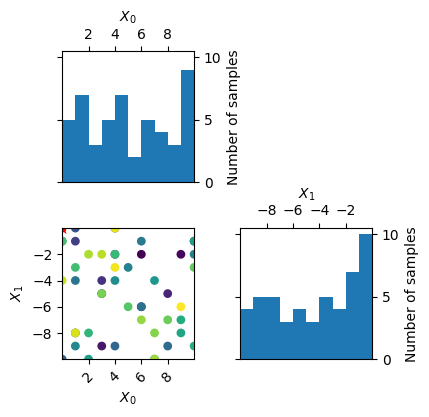

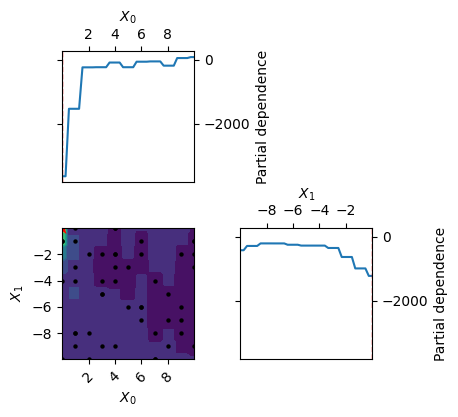

In [59]:
from skopt import gp_minimize

def objective(params):
    limit_buy, limit_sell = params
    stats = bt2.run(limit_buy=limit_buy, limit_sell=limit_sell)
    return -stats['Return [%]']  # Negative because we want to maximize

res = gp_minimize(
    objective,
    dimensions=[(0, 10), (-10, 0)],  # limit_buy and limit_sell ranges
    n_calls=50,
    random_state=0
)

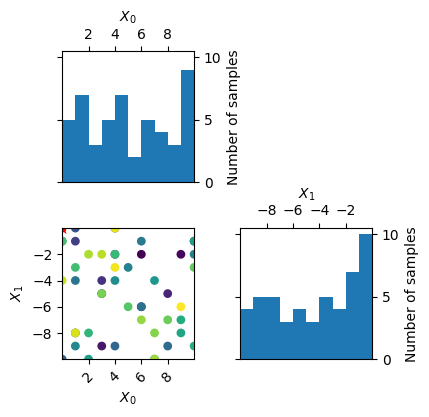

In [61]:
#dots = combos tried 
#red star = opt combo
#hsito grams = num of samples randomdly selected 

_ = plot_evaluations(res, bins=10)

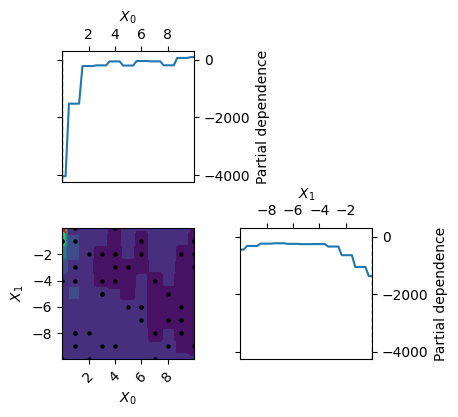

In [62]:
#density plot 
#shows heatmap of algo convergence towards opt value where it 
#finds opt point at red star
#gives indication of vals of limit buy and sll will be likely -> higher retruns 
_ = plot_objective(res)

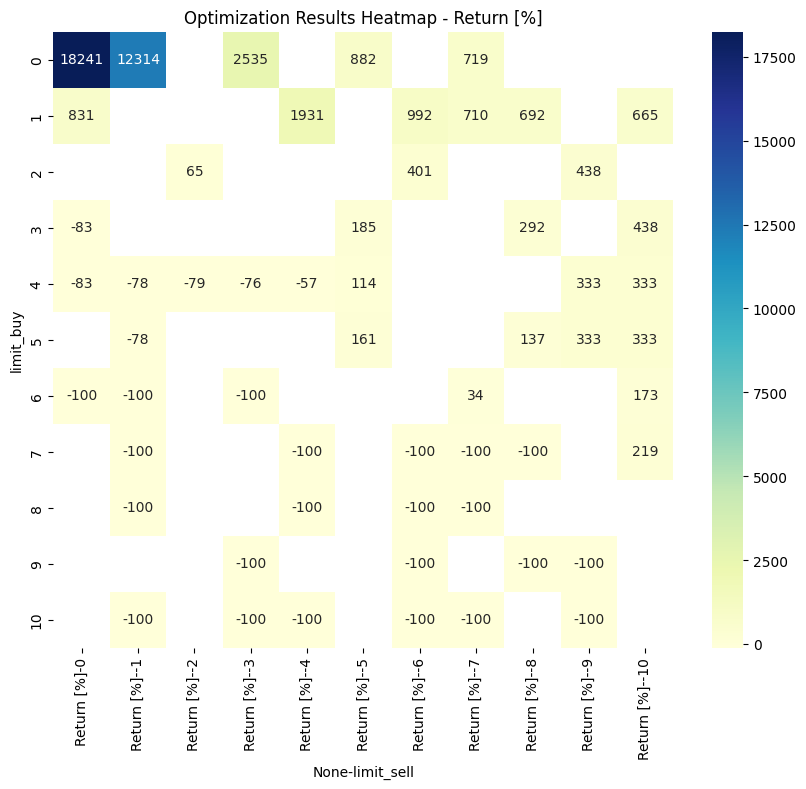

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(dff2.sort_index(axis=1, ascending=False), annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Optimization Results Heatmap - Return [%]')
plt.show()

In [ ]:
#_ = plot_objective(optimize_results, n_points=10)

In [ ]:
results2 = bt.run()

In [ ]:
results2.to_frame(name='Values').loc[:'Return [%]']

,Values
Start,2016-12-08 00:00:00
End,2025-05-22 00:00:00
Duration,3087 days 00:00:00
Exposure Time [%],76.329412
Equity Final [$],26123.028278
Equity Peak [$],27059.837957
Commissions [$],949.94761
Return [%],161.230283
